### Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:
- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

In [19]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
model=init_chat_model("groq:openai/gpt-oss-120b")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000265E105E270>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000265E105D880>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
- Long-running conversations that exceed context windows.
- Multi-turn dialogues with extensive history.
- Applications where preserving full conversation context matters.

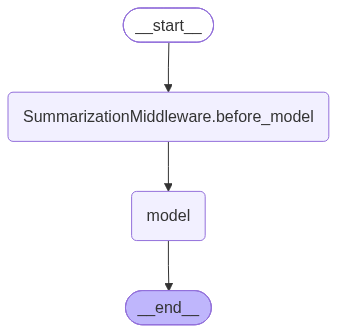

In [20]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

agent = create_agent(model="groq:openai/gpt-oss-120b",
                     checkpointer=InMemorySaver(),
                     middleware=[SummarizationMiddleware(model="groq:openai/gpt-oss-120b", trigger=("messages", 10),
                                                         keep=("messages", 4))])
agent

In [21]:
config = {"configurable":{"thread_id":"thread_1"}}

questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]

for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]},config)
    print(f"Messages: {response}")
    print(f"Messages: {len(response['messages'])}")


Messages: {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='fea12e5b-0f7f-4589-be57-1a2ec2964f6d'), AIMessage(content='2\u202f+\u202f2\u202f=\u202f4.', additional_kwargs={'reasoning_content': 'The user asks a simple math question: "What is 2+2?" Answer: 4.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 78, 'total_tokens': 119, 'completion_time': 0.084702073, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.005002561, 'prompt_tokens_details': None, 'queue_time': 0.377148162, 'total_time': 0.089704634}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff0c7-867f-7f72-a608-45ff2294fcf9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 78, 'output_tokens': 41, 'total_tokens': 119, 'output_token_details': {'reasoning': 22}})]

## token Size

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver


@tool
def search_hotel(city:str)->str:
    """ search hotels based on the city """
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""


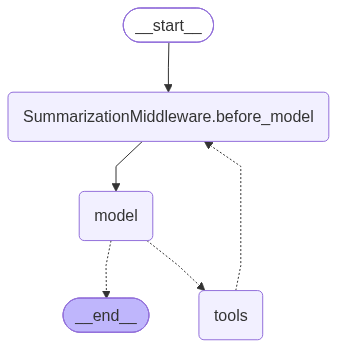

In [23]:
agent = create_agent(model="groq:openai/gpt-oss-120b", tools=[search_hotel], checkpointer=InMemorySaver(),
             middleware=[SummarizationMiddleware(model="groq:openai/gpt-oss-120b", trigger=("tokens", 400), keep=("tokens", 100))])

agent

In [24]:
config = {"configurable":{"thread_id":"test_1"}}
# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

In [25]:
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke({"messages":[HumanMessage(content=f"find the hotels in this{city}")]}, 
                  config=config)

    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~298 tokens, 4 messages
[HumanMessage(content='find the hotels in thisParis', additional_kwargs={}, response_metadata={}, id='be23c981-4d30-409b-ab45-00aea80f78e4'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to find hotels in "thisParis". Likely a typo: "thisParis". Probably they want hotels in Paris. Use the function search_hotel with city "Paris".', 'tool_calls': [{'id': 'fc_58e7a2af-ed29-4317-b26b-bc24b041f453', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotel'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 127, 'total_tokens': 193, 'completion_time': 0.140279566, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.005821026, 'prompt_tokens_details': None, 'queue_time': 0.258882428, 'total_time': 0.146100592}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9d1f936695', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs':

### Fraction

In [26]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="groq:openai/gpt-oss-120b",
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gpt-4o-mini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~289 tokens (0.2258%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='1050b8d5-1b32-4581-8dcc-407689a7e24a'), AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants hotels in Paris. Likely we need to call search_hotels with city "Paris".', 'tool_calls': [{'id': 'fc_354db094-bfaf-4dd7-9643-cc3d9868cfcf', 'function': {'arguments': '{"city":"Paris"}', 'name': 'search_hotels'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 120, 'total_tokens': 169, 'completion_time': 0.106988451, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.005805945, 'prompt_tokens_details': None, 'queue_time': 0.37727136, 'total_time': 0.112794396}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_90620edd96', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ff0c8-cd17-74b0-861e-1f19c

### Human In the Loop MiddleWare

Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [27]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

In [28]:
agent = create_agent(model="groq:openai/gpt-oss-120b", checkpointer=InMemorySaver(), 
                     middleware=[HumanInTheLoopMiddleware(
                         interrupt_on={"send_email_tool":{"allowed_decisions":["approve","edit","reject"]},
                                       "read_email_tool":False})])

In [29]:
config = {"configurable":{"thread_id":"test_approve"}}

result = agent.invoke({"messages":[HumanMessage(content="send email to john@gmail.com stating that i am doing good")]}, config=config)
result

{'messages': [HumanMessage(content='send email to john@gmail.com stating that i am doing good', additional_kwargs={}, response_metadata={}, id='6f1b5873-7cf8-44e8-9c39-cbae9fdf4a3e'),
  AIMessage(content='I’m not able to send emails directly, but I can help you draft one. Here’s a simple version you could use:\n\n---\n\n**Subject:** Quick Check‑in\n\nHi John,\n\nI hope you’re doing well. I just wanted to let you know that I’m doing good and everything’s going smoothly on my end.\n\nTalk soon!\n\nBest,  \n[Your Name]\n\n---\n\nFeel free to copy this into your email client, add any personal touches you’d like, and hit send. Let me know if you’d like any tweaks!', additional_kwargs={'reasoning_content': 'The user asks to send an email to john@gmail.com stating that "i am doing good". The user is requesting to send an email. According to policy, we cannot send emails on behalf of the user. We can provide a draft of the email, but cannot actually send it. So we should refuse to send but can

In [30]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

In [31]:
result

{'messages': [HumanMessage(content='send email to john@gmail.com stating that i am doing good', additional_kwargs={}, response_metadata={}, id='6f1b5873-7cf8-44e8-9c39-cbae9fdf4a3e'),
  AIMessage(content='I’m not able to send emails directly, but I can help you draft one. Here’s a simple version you could use:\n\n---\n\n**Subject:** Quick Check‑in\n\nHi John,\n\nI hope you’re doing well. I just wanted to let you know that I’m doing good and everything’s going smoothly on my end.\n\nTalk soon!\n\nBest,  \n[Your Name]\n\n---\n\nFeel free to copy this into your email client, add any personal touches you’d like, and hit send. Let me know if you’d like any tweaks!', additional_kwargs={'reasoning_content': 'The user asks to send an email to john@gmail.com stating that "i am doing good". The user is requesting to send an email. According to policy, we cannot send emails on behalf of the user. We can provide a draft of the email, but cannot actually send it. So we should refuse to send but can

### Reject

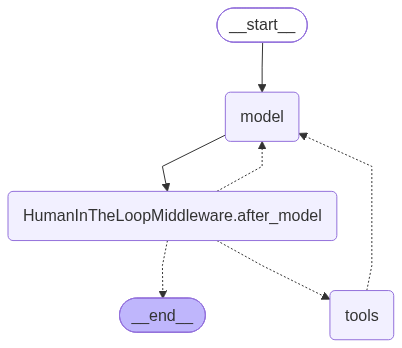

In [34]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
                HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)
agent

In [36]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='04fc1786-5f71-493e-ba96-30d70094d5a8'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email. Use send_email_tool.', 'tool_calls': [{'id': 'fc_64734b9d-5478-4722-9dd5-5a074c51c782', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 174, 'total_tokens': 232, 'completion_time': 0.124391695, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.00821762, 'prompt_tokens_details': None, 'queue_time': 0.287444199, 'total_time': 0.132609315}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_53dd116a39', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 

In [37]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: I’m unable to send the email because the previous attempt was cancelled. Would you like me to try sending it again, or would you prefer to handle it another way?


In [38]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='04fc1786-5f71-493e-ba96-30d70094d5a8'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to send email. Use send_email_tool.', 'tool_calls': [{'id': 'fc_64734b9d-5478-4722-9dd5-5a074c51c782', 'function': {'arguments': '{"body":"How are you?","recipient":"john@test.com","subject":"Hello"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 174, 'total_tokens': 232, 'completion_time': 0.124391695, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.00821762, 'prompt_tokens_details': None, 'queue_time': 0.287444199, 'total_time': 0.132609315}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_53dd116a39', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 

### Editing

In [40]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [41]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [42]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='7e7c09fc-40be-4038-91ec-f4d5fcc3354c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "User wants to send email to wrong@email.com with subject 'Test' and body 'Hello'. Use send_email_tool.", 'tool_calls': [{'id': 'fc_b6e1fb96-9d5e-4462-8666-a9b6cef65beb', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 172, 'total_tokens': 241, 'completion_time': 0.150722816, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.007871327, 'prompt_tokens_details': None, 'queue_time': 0.28272793, 'total_time': 0.158594143}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5082008e34', 'service_tier': 'on_demand', 'finish_reason': 'to

In [43]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: 


In [44]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='7e7c09fc-40be-4038-91ec-f4d5fcc3354c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "User wants to send email to wrong@email.com with subject 'Test' and body 'Hello'. Use send_email_tool.", 'tool_calls': [{'id': 'fc_b6e1fb96-9d5e-4462-8666-a9b6cef65beb', 'function': {'arguments': '{"body":"Hello","recipient":"wrong@email.com","subject":"Test"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 172, 'total_tokens': 241, 'completion_time': 0.150722816, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.007871327, 'prompt_tokens_details': None, 'queue_time': 0.28272793, 'total_time': 0.158594143}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5082008e34', 'service_tier': 'on_demand', 'finish_reason': 'to